In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller

In [2]:
df = pd.read_csv("data/money_transfers_en_with_exchange.csv")

Check for the missing values

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 194 entries, 0 to 193
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Year-Month  194 non-null    str    
 1   Inflows     194 non-null    float64
 2   Outflows    194 non-null    float64
 3   USD         194 non-null    float64
 4   EUR         194 non-null    float64
 5   RUR         194 non-null    float64
 6   EA_index    194 non-null    float64
dtypes: float64(6), str(1)
memory usage: 10.7 KB


In [4]:
df.shape

(194, 7)

1) Log-transformation applied

In [5]:
df_log = df.copy()

numeric_cols = df_log.select_dtypes(include='number').columns

df_log[numeric_cols] = np.log1p(df_log[numeric_cols])
df = df_log

In [6]:
df.head()

,Year-Month,Inflows,Outflows,USD,EUR,RUR,EA_index
0,2010-01-01,11.165018,10.510421,5.936295,6.289771,2.615204,3.933784
1,2010-02-01,11.380481,10.763846,5.944085,6.256997,2.611539,3.962716
2,2010-03-01,11.547209,10.908814,5.979417,6.284134,2.663750,3.979682
3,2010-04-01,11.564718,10.815919,5.980227,6.274498,2.676215,3.923952
4,2010-05-01,11.633991,10.931556,5.955837,6.184005,2.613740,3.921973


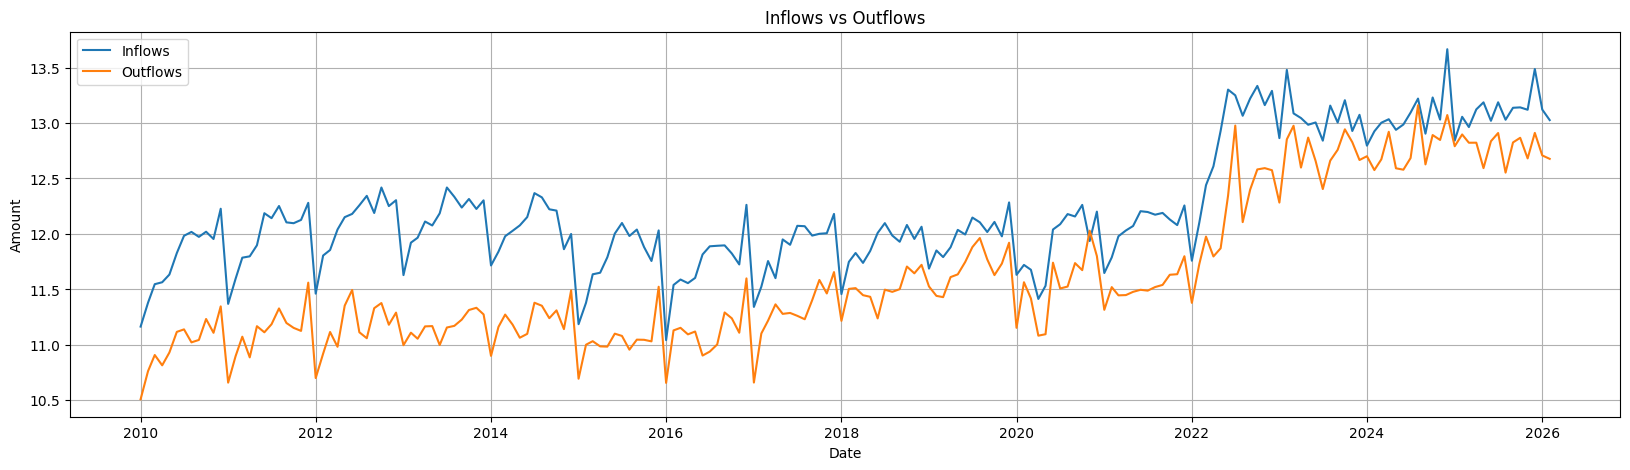

In [7]:
df['Year-Month'] = pd.to_datetime(df['Year-Month'])
df.set_index('Year-Month', inplace=True)

# -------------------
# 1. Inflows vs Outflows
# -------------------
plt.figure(figsize=(20,5))
plt.plot(df.index, df['Inflows'], label='Inflows')
plt.plot(df.index, df['Outflows'], label='Outflows')
plt.title('Inflows vs Outflows')
plt.xlabel('Date')
plt.ylabel('Amount')
# plt.xticks(df.index[::3], rotation=45)

plt.legend()
plt.grid(True)
plt.show()

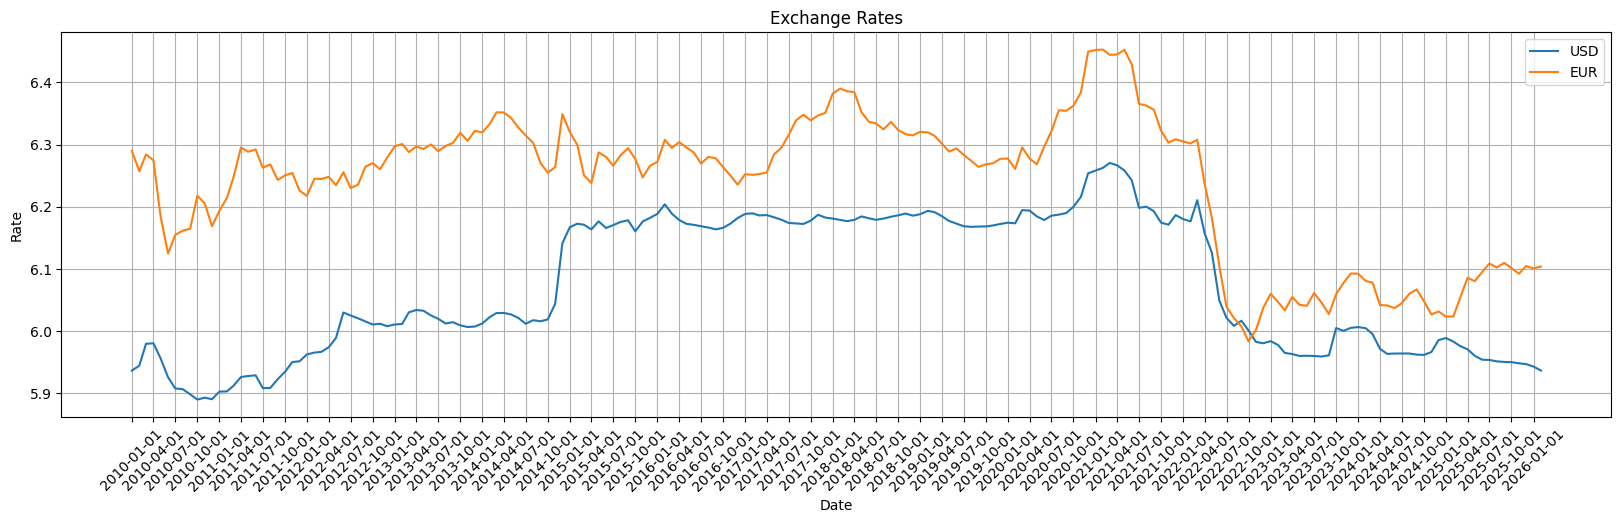

In [8]:
# -------------------
# 2. Exchange Rates
# -------------------
plt.figure(figsize=(20,5))
plt.plot(df.index, df['USD'], label='USD')
plt.plot(df.index, df['EUR'], label='EUR')
plt.title('Exchange Rates')
plt.xlabel('Date')
plt.ylabel('Rate')
plt.xticks(df.index[::3], rotation=45)
plt.legend()
plt.grid(True)
plt.show()

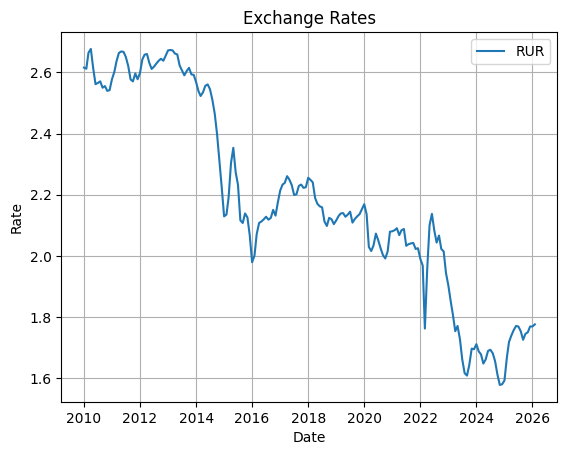

In [9]:
plt.plot(df.index, df['RUR'], label='RUR')
plt.title('Exchange Rates')
plt.xlabel('Date')
plt.ylabel('Rate')
plt.legend()
plt.grid(True)
plt.show()

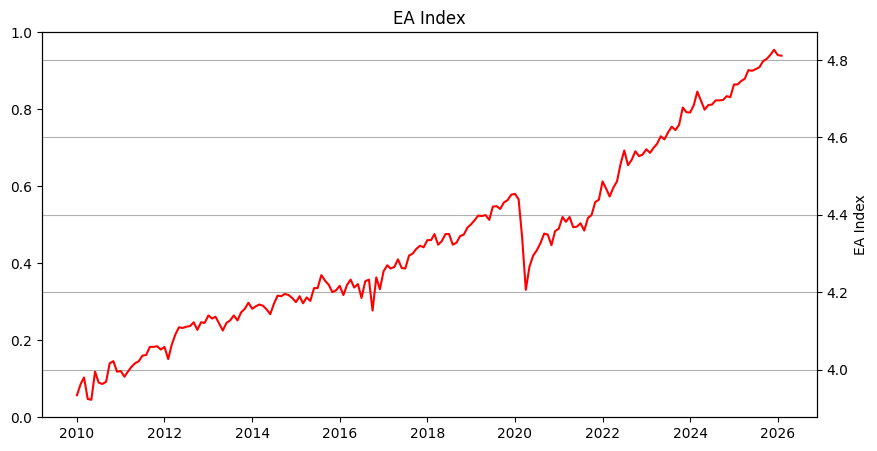

In [10]:
# -------------------
# 3. EA Index
# -------------------
fig, ax1 = plt.subplots(figsize=(10,5))

ax2 = ax1.twinx()
ax2.plot(df.index, df['EA_index'], label='EA_index', color='r')
ax2.set_ylabel('EA Index')

plt.title('EA Index')
plt.grid(True)
plt.show()

In [11]:
df.columns

Index(['Inflows', 'Outflows', 'USD', 'EUR', 'RUR', 'EA_index'], dtype='str')

In [12]:
# ==========================================
# 0. SETUP
# ==========================================
# ['Inflows', 'Outflows', 'USD', 'EUR', 'RUR', 'EA_index']
# and has a DatetimeIndex.

# Define historical break dates
break_1_date = "2014-08-01"
break_2_date = "2022-02-01"

# Create a time trend index (t = 1, 2, 3, ...)
df["t"] = np.arange(1, len(df) + 1)

# Find the integer index positions corresponding to the break dates
t_b1 = df.index.get_loc(pd.Timestamp(break_1_date)) + 1
t_b2 = df.index.get_loc(pd.Timestamp(break_2_date)) + 1

# --- Construct the Dummies ---
# Level shifts
df["D1"] = (df.index >= break_1_date).astype(int)
df["D2"] = (df.index >= break_2_date).astype(int)

# Trend shifts
df["DT1"] = (df["t"] - t_b1) * df["D1"]
df["DT2"] = (df["t"] - t_b2) * df["D2"]

In [13]:
# Helper function to create lagged and differenced variables easily
def prepare_adf_inputs(series, max_lags=4):
    """Generates first differences and lag structures for custom regressions."""
    data = pd.DataFrame({"y": series})
    data["dy"] = data["y"].diff()
    data["y_lag1"] = data["y"].shift(1)

    # Generate lagged differences for the augmentation part
    for i in range(1, max_lags + 1):
        data[f"dy_lag{i}"] = data["dy"].shift(i)

    return data.dropna()

In [14]:
# ==========================================
# BLOCK 1: SINGLE-BREAK SERIES (2022 Level-Shift / No Trend)
# ==========================================

single_break_vars = ["Inflows", "Outflows", "EUR"]

for var in single_break_vars:
    reg_data = prepare_adf_inputs(df[var])

    reg_data = reg_data.join(df[["D2"]])

    X_cols = [
        "D2",
        "y_lag1",
        "dy_lag1",
        "dy_lag2",
    ]

    X = sm.add_constant(reg_data[X_cols])
    y = reg_data["dy"]

    model = sm.OLS(y, X).fit()
    
    lambda_fraction = t_b1 / len(df)
    t_stat = model.tvalues["y_lag1"]
    print(f"\nVariable: {var}")
    print(f"Calculated Single Level-Break (2022) t-stat for rho: {t_stat:.4f}")
    print(
    f"--> Compare this value against Perron (1989) Model C tables for lambda = {lambda_fraction:.2f}."
    )


Variable: Inflows
Calculated Single Level-Break (2022) t-stat for rho: -6.5023
--> Compare this value against Perron (1989) Model C tables for lambda = 0.29.

Variable: Outflows
Calculated Single Level-Break (2022) t-stat for rho: -4.5016
--> Compare this value against Perron (1989) Model C tables for lambda = 0.29.

Variable: EUR
Calculated Single Level-Break (2022) t-stat for rho: -4.7816
--> Compare this value against Perron (1989) Model C tables for lambda = 0.29.


In [15]:
# ==========================================
# BLOCK 2: MULTI-BREAK LEVEL-SHIFT SERIES (USD)
# ==========================================
print("\n=== BLOCK 2: MULTI-BREAK LEVEL-SHIFT SERIES (USD) ===")

reg_data_usd = prepare_adf_inputs(df["USD"])

reg_data_usd = reg_data_usd.join(df[["D1", "D2"]])

X_cols_usd = [
    "D1",
    "D2",
    "y_lag1",
    "dy_lag1",
    "dy_lag2",
]

X_usd = sm.add_constant(reg_data_usd[X_cols_usd])
y_usd = reg_data_usd["dy"]

model_usd = sm.OLS(y_usd, X_usd).fit()
t_stat_usd = model_usd.tvalues["y_lag1"]

lambda_1 = t_b1 / len(df)
lambda_2 = t_b2 / len(df)

print(f"Variable: USD")
print(f"Break Fraction 1 (lambda 1 - 2014): {lambda_1:.2f}")
print(f"Break Fraction 2 (lambda 2 - 2022): {lambda_2:.2f}")
print(f"Calculated t-stat for rho: {t_stat_usd:.4f}")
print(
    f"--> Compare this value against Multi-Break Level-Shift Tables (Lumsdaine-Papell or Narayan-Popp) for the given break fractions."
)


=== BLOCK 2: MULTI-BREAK LEVEL-SHIFT SERIES (USD) ===
Variable: USD
Break Fraction 1 (lambda 1 - 2014): 0.29
Break Fraction 2 (lambda 2 - 2022): 0.75
Calculated t-stat for rho: -5.2394
--> Compare this value against Multi-Break Level-Shift Tables (Lumsdaine-Papell or Narayan-Popp) for the given break fractions.


In [16]:
# ==========================================
# BLOCK 3: SLOPING & TRENDING SERIES
# ==========================================
print("\n=== BLOCK 3: SLOPING & TRENDING SERIES (RUR, EA_index) ===")
trending_vars = ["RUR", "EA_index"]

for var in trending_vars:
    adf_result_level = adfuller(df[var], regression="ct", autolag="AIC")

    adf_result_diff = adfuller(df[var].diff().dropna(), regression="c", autolag="AIC")

    print(f"\nVariable: {var}")
    print("  [Log-Levels (with Constant & Trend)]")
    print(f"    ADF Statistic: {adf_result_level[0]:.4f}")
    print(f"    p-value:       {adf_result_level[1]:.4f}")
    print("  [First Differences (with Constant)]")
    print(f"    ADF Statistic: {adf_result_diff[0]:.4f}")
    print(f"    p-value:       {adf_result_diff[1]:.4f}")

    if adf_result_level[1] > 0.05 and adf_result_diff[1] <= 0.05:
        print("  Result: Strictly I(1) - Ideal for VECM.")
    elif adf_result_level[1] <= 0.05:
        print(
            "  Warning: Rejects unit root at levels. Series might be Trend-Stationary I(0)."
        )
    else:
        print("  Warning: First difference is still non-stationary.")


=== BLOCK 3: SLOPING & TRENDING SERIES (RUR, EA_index) ===

Variable: RUR
  [Log-Levels (with Constant & Trend)]
    ADF Statistic: -2.4653
    p-value:       0.3455
  [First Differences (with Constant)]
    ADF Statistic: -9.3312
    p-value:       0.0000
  Result: Strictly I(1) - Ideal for VECM.

Variable: EA_index
  [Log-Levels (with Constant & Trend)]
    ADF Statistic: -2.7886
    p-value:       0.2012
  [First Differences (with Constant)]
    ADF Statistic: -15.5613
    p-value:       0.0000
  Result: Strictly I(1) - Ideal for VECM.


In [17]:
from statsmodels.tsa.vector_ar.vecm import coint_johansen

# ==========================================
# STEP 3: MULTIVARIATE JOHANSEN COINTEGRATION TEST
# ==========================================
print("=" * 70)
print(
    "STEP 3: MULTIVARIATE JOHANSEN COINTEGRATION TEST (SYSTEM INTEGRATION DETECTOR)"
)
print("=" * 70)

endog_vars = ["Outflows", "USD", "EUR", "RUR", "EA_index", "Inflows"]

df_johansen = df[endog_vars].dropna()

det_order = 0

k_ar_diff = 1

print(f"Analyzing Endogenous System Vector: {endog_vars}")
print(f"Lag length specified for differenced terms (k_ar_diff): {k_ar_diff}\n")

johansen_res = coint_johansen(df_johansen, det_order, k_ar_diff)

trace_stat = johansen_res.lr1
max_eig_stat = johansen_res.lr2
cv_trace = johansen_res.cvt  # Columns mapping: [10%, 5%, 1%]
cv_max_eig = johansen_res.cvm  # Columns mapping: [10%, 5%, 1%]

print("=" * 70)
print("                    JOHANSEN TRACE TEST RESULTS                      ")
print("=" * 70)
print(
    f"{'Null Hypothesis':<15} | {'Trace Stat':<12} | {'10% CV':<9} | {'5% CV':<9} | {'1% CV':<9}"
)
print("-" * 70)

for i in range(len(endog_vars)):
    null_hypo = f"r <= {i}"
    print(
        f"{null_hypo:<15} | {trace_stat[i]:<12.4f} | {cv_trace[i, 0]:<9.4f} | {cv_trace[i, 1]:<9.4f} | {cv_trace[i, 2]:<9.4f}"
    )

print("\n" + "=" * 70)
print("              JOHANSEN MAXIMUM EIGENVALUE TEST RESULTS               ")
print("=" * 70)
print(
    f"{'Null Hypothesis':<15} | {'Max-Eig Stat':<12} | {'10% CV':<9} | {'5% CV':<9} | {'1% CV':<9}"
)
print("-" * 70)

for i in range(len(endog_vars)):
    null_hypo = f"r = {i}"
    print(
        f"{null_hypo:<15} | {max_eig_stat[i]:<12.4f} | {cv_max_eig[i, 0]:<9.4f} | {cv_max_eig[i, 1]:<9.4f} | {cv_max_eig[i, 2]:<9.4f}"
    )

print("\n" + "=" * 70)
print("ECONOMIC SPECIFICATION ROUTE DECISION:")
print("-" * 70)

confirmed_rank = 0
for i in range(len(endog_vars)):
    if trace_stat[i] > cv_trace[i, 1]:
        confirmed_rank = i + 1
    else:
        break

print(f"Empirically Determined Cointegration Rank (r) = {confirmed_rank}")

if confirmed_rank == 0:
    print("\nResult: NO COINTEGRATION DETECTED.")
    print(
        "--> Interpretation: The series drift independently; no shared long-run equilibrium exists."
    )
    print(
        "--> PIPELINE CONCLUSION: A VECM is mathematically invalid. You must change course"
    )
    print(
        "    and initialize an unconstrained VAR model fitted on FIRST DIFFERENCES."
    )
elif confirmed_rank == len(endog_vars):
    print("\nResult: FULL RANK IMPLIED (r = N).")
    print(
        "--> Warning: This mathematically contradicts unit root results and implies"
    )
    print(
        "    that all series are actually stationary I(0). Re-verify data transformations."
    )
else:
    print(f"\nResult: COINTEGRATION CONFIRMED (Rank r = {confirmed_rank})")

STEP 3: MULTIVARIATE JOHANSEN COINTEGRATION TEST (SYSTEM INTEGRATION DETECTOR)
Analyzing Endogenous System Vector: ['Outflows', 'USD', 'EUR', 'RUR', 'EA_index', 'Inflows']
Lag length specified for differenced terms (k_ar_diff): 1

                    JOHANSEN TRACE TEST RESULTS                      
Null Hypothesis | Trace Stat   | 10% CV    | 5% CV     | 1% CV    
----------------------------------------------------------------------
r <= 0          | 139.4119     | 91.1090   | 95.7542   | 104.9637 
r <= 1          | 77.2385      | 65.8202   | 69.8189   | 77.8202  
r <= 2          | 37.1448      | 44.4929   | 47.8545   | 54.6815  
r <= 3          | 13.5651      | 27.0669   | 29.7961   | 35.4628  
r <= 4          | 3.4410       | 13.4294   | 15.4943   | 19.9349  
r <= 5          | 0.0092       | 2.7055    | 3.8415    | 6.6349   

              JOHANSEN MAXIMUM EIGENVALUE TEST RESULTS               
Null Hypothesis | Max-Eig Stat | 10% CV    | 5% CV     | 1% CV    
---------------------

In [18]:
# ==========================================
# STEP 4: VECM ESTIMATION WITH EXOGENOUS STRUCTURAL BREAKS
# ==========================================
print("=" * 60)
print("STEP 4: ESTIMATING THE STRUCTURAL VECM SYSTEM")
print("=" * 60)

from statsmodels.tsa.vector_ar.vecm import VECM, select_order

df = df.asfreq("MS")

# ------------------------------------------
# 1. DEFINE ENDOGENOUS AND EXOGENOUS SYSTEMS
# ------------------------------------------

endog_df = df[
    ["Outflows", "USD", "EUR", "RUR", "EA_index", "Inflows"]
]
# These are treated as external shocks and are not modeled recursively within the VECM system.
exog_df = df[["D1", "D2", "DT1", "DT2"]]

lag_selection = select_order(
    endog_df,
    maxlags=4,
    deterministic="co",
    exog=exog_df,
)

print(lag_selection.summary())

optimal_k = lag_selection.aic

callibrated_k_diff = optimal_k - 1

print(
    f"\nSelected Lags for First Differences "
    f"(k_ar_diff): {callibrated_k_diff}"
)

vecm_model = VECM(
    endog=endog_df,
    exog=exog_df,
    k_ar_diff=callibrated_k_diff,
    coint_rank=2,
    deterministic="co",
)

# Estimate the full VECM system
vecm_results = vecm_model.fit()

# ------------------------------------------
# 6. EXPORT MODEL SUMMARY
# ------------------------------------------

# Convert the estimation summary into plain text
summary_text = vecm_results.summary().as_text()

# Preview first portion in console
print("\n" + "=" * 60)
print("VECM MODEL ESTIMATION SUMMARY (PREVIEW)")
print("=" * 60)

print(summary_text[:1200])

# ------------------------------------------
# 7. SAVE FULL REPORT TO FILE
# ------------------------------------------

output_file = "report.md"

with open(output_file, "w", encoding="utf-8") as f:

    f.write("=" * 80 + "\n")
    f.write(
        "(VECM) ESTIMATION REPORT\n"
    )
    f.write("=" * 80 + "\n\n")

    f.write(summary_text)

print(
    f"Success! Full VECM estimation report "
    f"saved to '{output_file}'."
)

STEP 4: ESTIMATING THE STRUCTURAL VECM SYSTEM
 VECM Order Selection (* highlights the minimums)
      AIC         BIC         FPE         HQIC   
-------------------------------------------------
0      -37.63     -36.40*   4.537e-17     -37.13*
1     -37.80*      -35.95  3.843e-17*      -37.05
2      -37.74      -35.27   4.106e-17      -36.74
3      -37.56      -34.47   4.963e-17      -36.31
4      -37.39      -33.69   5.922e-17      -35.89
-------------------------------------------------

Selected Lags for First Differences (k_ar_diff): 0

VECM MODEL ESTIMATION SUMMARY (PREVIEW)
Det. terms outside the coint. relation & lagged endog. parameters for equation Outflows
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         14.4855      1.074     13.491      0.000      12.381      16.590
exog1         -0.0940      0.048     -1.963      0.050      -0.188      -0.000
exog2  

In [19]:
# ==========================================
# STEP 5: VECM POST-ESTIMATION DIAGNOSTICS
# ==========================================
print("=" * 60)
print("STEP 5: COMPREHENSIVE VECM DIAGNOSTIC TESTING")
print("=" * 60)

lm_test = vecm_results.test_whiteness(nlags=3)
print("\n[1] RESIDUAL WHITENESS TEST (SERIAL CORRELATION):")

try:
    stat_val = lm_test.test_stat
except AttributeError:
    try:
        stat_val = lm_test.stat
    except AttributeError:
        stat_val = None

if stat_val is not None:
    print(f"LM Test Statistic: {stat_val:.4f}")
print(f"P-value:           {lm_test.pvalue:.4f}")

if lm_test.pvalue > 0.05:
    print(
        "--> No serial correlation detected. Standard errors and p-values are fully trusted."
    )
else:
    print(
        "--> Residuals suffer from autocorrelation. We may need to adjust our lag selection."
    )

# Test for Normality (Multivariate Jarque-Bera)
norm_test = vecm_results.test_normality()
print("\n[2] RESIDUAL NORMALITY TEST (JARQUE-BERA):")

try:
    jb_stat = norm_test.test_stat
except AttributeError:
    try:
        jb_stat = norm_test.stat
    except AttributeError:
        jb_stat = None

if jb_stat is not None:
    print(f"JB Test Statistic: {jb_stat:.4f}")
print(f"P-value:           {norm_test.pvalue:.4f}")

if norm_test.pvalue > 0.05:
    print("--> Residuals are normally distributed.")
else:
    print(
        "--> Residuals are non-normal. (This is incredibly common in macroeconomic data containing heavy-tailed shocks like 2022)."
    )

# Dynamic Stability Summary
print("\n[3] COINTEGRATION STRUCTURAL SUMMARY:")
print(
    f"Enforced Cointegration Rank: {vecm_results.coint_rank}")
print("=" * 60)

STEP 5: COMPREHENSIVE VECM DIAGNOSTIC TESTING

[1] RESIDUAL WHITENESS TEST (SERIAL CORRELATION):
P-value:           0.0000
--> Residuals suffer from autocorrelation. We may need to adjust our lag selection.

[2] RESIDUAL NORMALITY TEST (JARQUE-BERA):
P-value:           0.0000
--> Residuals are non-normal. (This is incredibly common in macroeconomic data containing heavy-tailed shocks like 2022).

[3] COINTEGRATION STRUCTURAL SUMMARY:
Enforced Cointegration Rank: 2


GENERATING ANNOTATED PERCENTAGE IRF CHARTS


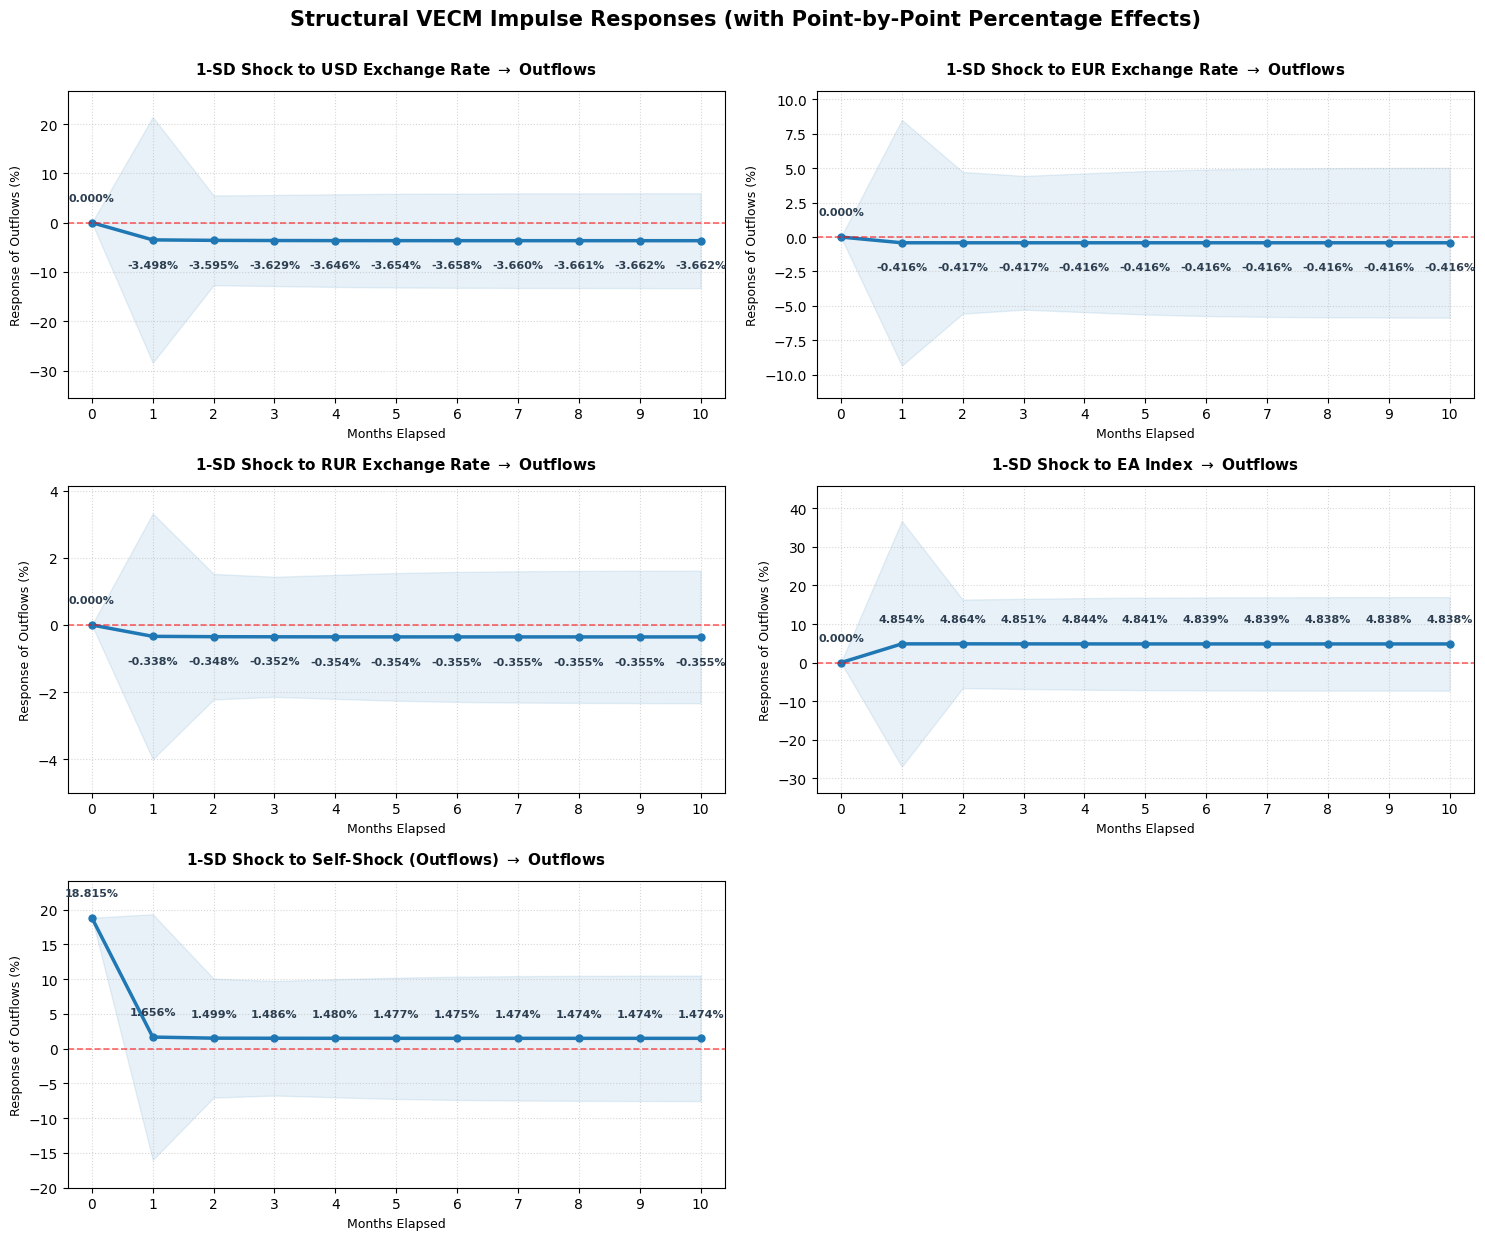

In [20]:
print("=" * 60)
print("GENERATING ANNOTATED PERCENTAGE IRF CHARTS")
print("=" * 60)

irf_horizon = 10
irf = vecm_results.irf(periods=irf_horizon)
irf_err = irf.stderr()

var_mapping = {
    "USD Exchange Rate": 1,
    "EUR Exchange Rate": 2,
    "RUR Exchange Rate": 3,
    "EA Index": 4,
    "Self-Shock (Outflows)": 0,
}

fig, axes = plt.subplots(3, 2, figsize=(15, 12))
axes = axes.flatten()

for i, (var_name, var_idx) in enumerate(var_mapping.items()):
    ax = axes[i]

    response = irf.orth_irfs[:, 0, var_idx] * 100
    stderr_response = irf_err[:, 0, var_idx] * 100

    lower_bound = response - 1.96 * stderr_response
    upper_bound = response + 1.96 * stderr_response
    time_steps = np.arange(irf_horizon + 1)

    ax.plot(
        time_steps,
        response,
        color="#1f77b4",
        lw=2.5,
        marker="o",
        markersize=5,
        label="Response",
    )
    ax.fill_between(
        time_steps, lower_bound, upper_bound, color="#1f77b4", alpha=0.10
    )

    for x, y in zip(time_steps, response):
        offset = 0.08 * (upper_bound.max() - lower_bound.min())
        va_dir = "bottom" if y >= 0 else "top"
        y_pos = y + offset if y >= 0 else y - offset

        ax.text(
            x,
            y_pos,
            f"{y:.3f}%",
            ha="center",
            va=va_dir,
            fontsize=8,
            color="#2c3e50",
            weight="semibold",
        )

    ax.axhline(0, color="red", linestyle="--", alpha=0.6, lw=1.2)

    y_min = min(lower_bound.min(), -0.05) - (
        0.25 * abs(min(lower_bound.min(), -0.05))
    )
    y_max = max(upper_bound.max(), 0.05) + (
        0.25 * abs(max(upper_bound.max(), 0.05))
    )
    ax.set_ylim(y_min, y_max)

    ax.set_title(
        f"1-SD Shock to {var_name} $\\rightarrow$ Outflows",
        fontsize=11,
        pad=12,
        weight="bold",
    )
    ax.set_xlabel("Months Elapsed", fontsize=9)
    ax.set_ylabel("Response of Outflows (%)", fontsize=9)
    ax.grid(True, linestyle=":", alpha=0.5)
    ax.set_xlim(-0.4, irf_horizon + 0.4)
    ax.set_xticks(time_steps)

fig.delaxes(axes[5])

plt.tight_layout()
plt.suptitle(
    "Structural VECM Impulse Responses (with Point-by-Point Percentage Effects)",
    fontsize=15,
    y=1.03,
    weight="bold",
)
plt.show()

print("=" * 60)